# 神经网络启蒙：PyTorch 入门实战

本章我们将正式迈入神经网络的大门，从零开始构建并训练你的第一个神经网络模型。通过本次任务，你将会了解神经网络模型的基本结构、训练流程，并掌握如何使用深度学习框架 PyTorch 快速搭建并进行训练一个多参数回归模型。

## 任务背景

你是一名程序员。自从上次与小美合作，成功教会机器人制作柠檬水后，你的无人柠檬水摊位生意渐火。看着账户里稳定增长的收入，一个更大胆的想法浮现出来：如果只卖经典原味柠檬水，市场天花板显而易见；但如果能让机器人学会开发多种口味的特调柠檬水，必将大大提升产品的吸引力和营收潜力。

你尝试在基础柠檬水中加入薄荷叶、百香果、黄瓜片或少许玫瑰盐，以创造不同的风味。薄荷带来清凉感，黄瓜增加清新的后韵，而一点点玫瑰盐则能神奇地提升整体的层次感——但这些配料之间会相互影响，如何平衡它们才是真正的艺术。

你不断尝试各种配比组合，邀请顾客品尝并记录评分，逐步优化配方。然而，这种试错过程漫长且成本高昂。于是你想：如果能训练一个模型，自动根据配料配比预测顾客评分，问题便可迎刃而解。

## 最少必要知识

- 神经网络概论
- PyTorch 基础

## 任务鸟瞰

本次的任务是：训练一个模型，根据薄荷叶、百香果、黄瓜片和玫瑰盐的配比，预测顾客对柠檬水的评分。

![image.png](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260204171547.png)

预测一杯柠檬水的口感评分，看似简单，实则受到多种参数的复杂影响。薄荷叶的多少、黄瓜片的厚薄、玫瑰盐的用量……这些细微变量都在悄然塑造着最终的口感体验。面对如此纷繁的因素，我们难以通过手动方式去管理每一个参数，因为很难精确描述它们与口感评分之间的复杂关系。

此时，不妨观察人类如何对柠檬水进行评分，并尝试从生物神经元的机制中汲取灵感。

### 神经网络

在大脑中，神经元是信息处理的基本单元。一个神经元会接收外界的刺激信号，神经突触根据输入信号的重要性进行加权处理；当加权后的信号总和超过某个阈值时，神经元被激活，产生输出信号。

神经元工作过程可分为两步：
- **加权求和**：对多个输入信号进行加权融合；
- **点火激活**：若加权和超过阈值，则触发输出。

当我们品尝柠檬水并给出评分时，大脑中的神经元正在进行类似处理。味觉、嗅觉等感官接收到的特征信息（薄荷的清香、黄瓜的清爽、玫瑰盐的风味等）被传递至相关神经元，经过加权整合，最终形成对口感的综合评判，即评分。

我们可以将上述过程抽象为人工神经元模型。单个神经元的计算可表示为：**输出 = 激活函数(Σ(权重 × 输入) + 偏置)**。

计算的过程如下图所示：

![image.png](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260204171554.png)

其中：
- $x$：输入信号
- $w$：权重
- $b$：偏置（可视为阈值）
- $∑$：加权求和
- $σ$：激活函数
- $y$：输出信号

更进一步，我们可以将神经元结构表示为数学公式：
$y = σ(w_1x_1 + w_2x_2 + w_3x_3 + ... + w_nx_n + b)$

### 模型结构

由大量神经元相互连接形成的系统称为神经网络（Neural Network）。本次任务我们使用神经网络，构建一个用于预测柠檬水评分的模型，学习三种配料与评分之间的关系。其模型结构如下：

![image.png](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260204171602.png)

本次的任务也是一个简单的多参数回归模型，所以我们只它使用一个神经网络层构建模型即可，这个神经网络层有3个输入和1个输出。

开发神经网络模型和机器学习模型一样，通常也遵循以下四个步骤：数据准备、模型定义、模型训练与模型评估。下文将依此流程组织内容。

### 环境版本

在开始之前，我们先打印环境的版本号，避免因为环境不同而导致程序不能复现。

In [1]:
from util import show_version

show_version()


本书愿景：
+------+--------------------------------------------------------+
| Info |                   《动手学人工智能》                   |
+------+--------------------------------------------------------+
| 作者 |                       吾辈亦有感                       |
| 哔站 |      https://space.bilibili.com/3461565265217538       |
| 定位 | 基于'从零构建'的理念，用实战帮助程序员快速入门大模型。 |
| 愿景 | 若让你的AI学习之路走的更容易一点，我将倍感荣幸！祝好😄 |
+------+--------------------------------------------------------+

环境信息：
+-------------+--------------+------------------------+
| Python 版本 | PyTorch 版本 | PyTorch Lightning 版本 |
+-------------+--------------+------------------------+
|   3.12.12   |    2.9.1     |         2.6.0          |
+-------------+--------------+------------------------+


## 数据准备

```{div} alert alert-light simple-tilt custom-card

<a href="https://t.zsxq.com/mAjcy" onclick="LA.track('dataset'); return true;">
    <div>
        <div style="display: flex; align-items: center">
            <img src="https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/logo.png" style="width: 128px">
            <div style="margin-left: 20px">
                <h4 class="card-title mt-3">数据集下载</h4>
                <p class="card-text">
                    如果你想要亲自动手复现运行结果，可以点击此链接下载相关数据集。
                </p>
            </div>
        </div>
    </div>
</a>
```


### 观察数据

加载并预览数据集前5行，了解数据结构。


In [2]:
# 读取数据
import pandas as pd

# 读取训练集数据
train_data_frame = pd.read_csv('./dataset/craft_lemonade_train.csv')
train_data_frame[:5]

,薄荷叶,黄瓜片,玫瑰盐,顾客评分
0,9,10,6,8.60
1,10,9,7,8.90
2,5,3,7,4.80
3,3,4,6,4.10
4,4,9,2,5.25


从输出结果可以看到数据包含四个字段：薄荷叶、黄瓜片、玫瑰盐（输入特征）和 顾客评分（目标值）。我们需要将每一条训练数据转化成 `<输入特征, 目标值>` 数据对的形式。

### 定义数据加载方法

根据文件路径加载 `csv` 数据，分离出输入特征与对应的目标值标签。

In [3]:
def load_data(file_path):
    # 读取 csv 数据
    data_frame = pd.read_csv(file_path)

    # 将DataFrame数据转换为列表格式
    features = data_frame[['薄荷叶', '黄瓜片', '玫瑰盐']].values.tolist()
    target_scores = data_frame[['顾客评分']].values.tolist()

    return features, target_scores

### 加载训练集和评估集

加载训练数据和评估数据，并打印训练集和评估集的样本数量，确认数据加载成功。

In [4]:
train_features, train_targets = load_data('./dataset/craft_lemonade_train.csv')
val_features, val_targets = load_data('./dataset/craft_lemonade_val.csv')

print(f"训练数据集样本数量：{len(train_features)}")
print(f"评估数据集样本数量：{len(val_features)}")

训练数据集样本数量：800
评估数据集样本数量：200


## 模型定义

### PyTorch 核心概念

要构建并训练一个神经网络模型，离不开强大的深度学习框架。PyTorch 以其灵活性、Python 友好的设计而广受欢迎，它提供了直观的接口来构建和调试复杂神经网络，是目前入门人工智能的主流选择之一。

为了顺利搭建柠檬水评分预测模型，我们需要了解以下 PyTorch 的核心概念：

| 概念         | 说明                                  |
|------------|-------------------------------------|
| 张量（Tensor） | PyTorch 中数据的基本单元，配料配比、评分等参数都需转换为张量。 |
| 网络层（Layer） | 模型处理数据的基本模块，需明确其输入输出维度。             |
| 模型（Model）  | 多个网络层的有序堆叠，形成完整的神经网络模型。             |

> Pytorch详细教程可参考：https://www.runoob.com/pytorch/pytorch-basic.html

### 柠檬水评分预测模型的模型结构

本次任务我们使用 PyTorch 训练一个预测 3 种配料与顾客评分之间关系的神经网络模型。

回顾一下模型结构：

![image.png](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260204171602.png)


### 柠檬水评分预测模型的代码实现

定义一个继承自 `nn.Module` 的柠檬水评分模型类 `LemonadeRatingModel`，这是 PyTorch 中定义神经网络模型的标准方式。

In [5]:
import torch
import torch.nn as nn


# 定义柠檬水评分预测模型,继承自 nn.Module，这是PyTorch中定义神经网络的标准方式
class LemonadeRatingModel(nn.Module):
    def __init__(self):
        super(LemonadeRatingModel, self).__init__()
        # 创建一个线性层：接受3个输入特征（薄荷叶、黄瓜片、玫瑰盐）并输出1个值（顾客评分）
        self.rating_predictor_layer = nn.Linear(in_features=3, out_features=1, bias=False)

    def forward(self, input_features):
        # 前向计算，定义数据在网络中的流动方式，预测顾客评分，forward 方法会被自动调用
        predicted_rating = self.rating_predictor_layer(input_features)
        return predicted_rating

自定义模型时， 需要重写模型的`__init__`和`forward`方法，分别完成模型的初始化和前向计算。
- `__init__()`：定义模型的参数和层结构，创建一个拥有 3 个输入特征，1 个输出特征的线性层（Linear）。
- `forward()`：定义数据在网络中的流动方式，通过前向计算根据输入特征预测顾客评分。

:::{admonition} 线性层
:class: note

在 PyTorch 中，线性层（Linear Layer）是最基础、最常用的神经网络层之一，由于它的每一个神经元都接收来自上一层所有神经元的输入信号，并与每个输入都有一个独立的权重进行连接，所以也称它为“全连接层”。

在PyTorch中，线性层由 `torch.nn.Linear` 类实现。它的主要参数有：

- `in_features`：输入特征的数量（即输入的维度）
- `out_features`：输出特征的数量（即输出的维度）
- `bias`：布尔值，表示是否使用偏置项，默认为True

当创建一个 Linear 实例时，它会自动初始化权重和偏置。
:::

### 柠檬水评分预测模型的结构详情

创建一个模型实例，并打印模型结构，确认模型创建成功。

In [6]:
from course_01.util import print_red

# 创建模型实例
model = LemonadeRatingModel()

print_red("模型结构：")
print(model)

模型结构：
LemonadeRatingModel(
  (rating_predictor_layer): Linear(in_features=3, out_features=1, bias=False)
)


从运行结果可以看到，柠檬水评分模型中只有一个预测评分的线性层 `rating_predictor_layer`，它有 3 个输入（薄荷叶、黄瓜片、玫瑰盐）、1 个输出（顾客评分）。

## 模型训练

### 神经网络的训练

既然生物神经网络能产生智能，那么仿照其结构构建的人工神经网络也应具备某种“学习能力”。神经网络的“学习”是指从训练数据中自动获取最优权重参数的过程。神经网络学习思路极其简单：计算神经网络得出的预测值与正解的误差，根据误差更新神经网络的权重，最终使得模型的误差总和达到最小。

使用 PyTorch 训练神经网络模型的流程如下：

![image.png](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260204171609.png)

训练神经网络模型和机器学习的流程基本一致，但也稍有不同：
1. 初始化模型：确定模型结构，并对模型参数进行随机初始化。
2. 前向传播：通过 `forward()` 将输入数据输入模型，得到预测结果。 
3. 损失计算：使用损失函数 `loss_fn()` 计算模型预测结果与真实结果之间的误差，评估模型性能。
4. 梯度计算：由于神经网络的参数成千上万，无法再手动计算每一个参数的更新方式，利用反向传播算法 `backward()` 自动计算损失对各参数的梯度，指导参数更新方向。
5. 参数更新：同样由于参数规模的暴增，手动更新参数也不太可能。另外学习率调度也非常复杂，需要借助优化器 `optimizer` 更新模型参数。
6. 重复执行 2～5 步，通过持续训练逐步优化模型，最终得到使损失最小化的模型参数。

每完成一次在数据集上的训练循环，我们称之为一个轮次，也就是 `epoch`。下面我们定义一个训练方法开始训练顾客评分模型。

### 定义训练方法

PyTorch 经典的训练循环如图所示：

![image.png](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260204171617.png)

下面定义训练神经网络模型的方法 `train_model`，指定训练轮次并在每一轮中执行完整的训练循环。同时，需定期记录训练过程中损失值，以便追踪模型训练的进度。

In [7]:
def train_model(model, train_features, train_targets, loss_fn, optimizer, num_epochs=100, log_interval=5):
    """
    训练模型并记录训练日志
    
    参数:
    model: 要训练的模型
    train_features: 训练特征数据张量
    train_targets: 训练标签数据张量
    loss_fn: 损失函数
    optimizer: 优化器
    num_epochs: 训练轮数，默认为100
    log_interval: 日志记录间隔，默认为5
    
    返回:
    training_logs: 包含训练过程记录的列表
    """

    training_logs = []

    for epoch in range(num_epochs):
        # 1. 前向传播：使用模型预测评分
        predictions = model(train_features)

        # 2. 计算损失：使用损失函数计算预测评分与真实分数的差距
        loss = loss_fn(predictions, train_targets)

        # 3. 清空梯度：将模型参数的梯度清空，避免梯度累积
        optimizer.zero_grad() 
        
        # 4. 反向传播，计算梯度
        loss.backward()

        # 5. 使用优化器，更新参数
        optimizer.step() 


        # 记录训练日志
        if (epoch + 1) % log_interval == 0:
            # 记录模型参数
            with torch.no_grad():
                for param_name, param in model.named_parameters():
                    if param.requires_grad:  # 筛选需要计算计算梯度进行更新的参数
                        weights_list = param.data.numpy()[0].tolist()

                        # 获取模型权重
                        mint_leaf_weight, cucumber_slice_weight, rose_salt_weight = weights_list[0], weights_list[1], weights_list[2]

                        # 记录训练日志
                        training_logs.append({
                            "Epoch": epoch + 1,
                            "Loss": loss.item(),
                            "薄荷叶权重": mint_leaf_weight,
                            "黄瓜片权重": cucumber_slice_weight,
                            "玫瑰盐权重": rose_salt_weight
                        })

    return training_logs

在神经网络模型的训练循环中，每个训练循环通常包含以下核心操作：

- **前向传播**：通过 `model()` 自动执行前向传播计算，模型会基于输入特征（如薄荷叶、黄瓜片、玫瑰盐的用量）计算预测输出（例如顾客评分）。
- **损失计算**：调用 `loss_fn()` 利用损失函数量化模型预测值与真实标签之间的差异，反映当前预测的误差大小。
- **清空历史梯度**：执行 `optimizer.zero_grad()` 将优化器中之前累积的梯度清零，以避免梯度累加影响本轮参数更新。
- **反向传播**：通过 `loss.backward()` 系统会自动计算损失对模型各参数的梯度，从而确定参数调整的方向与幅度。
- **参数更新**：使用 `optimizer.step()` 优化器将根据计算得到的梯度更新模型参数，使模型预测逐步向真实值靠近。

这些步骤在训练过程中循环执行，直至训练结束。

### 训练模型

定义好了训练方法后，可以开始训练模型了。训练模型需要以下步骤：
1. **超参数配置**：定义训练轮数、日志记录间隔、学习率等超参数
2. **准备训练数据**：将训练的输入数据和标签数据转换为张量
3. **初始化模型训练组件**：创建模型实例、损失函数和优化器
    - **损失函数**：因为此任务为回归任务，使用均方误差损失函数（MSE）
    - **优化器**：使用随机梯度下降（SGD）优化器优化模型参数，学习率为 `0.001`
4. **执行训练循环**：调用 `train_model` 函数进行 `500` 轮训练，每 `20` 轮记录一次训练日志。

:::{admonition} 损失函数：均方误差（MSE）
:class: note
MSE 是 `均方误差` 的缩写，英文全称是 Mean Squared Error。它是评估预测模型（如回归模型）精度最常用、最重要的指标之一。MSE 衡量的是模型预测值与真实值之间差异（即误差）的平方的平均值。

简单来说：
- 先算出每一个预测值和对应的真实值差多少。
- 把这个差值平方（目的是消除正负号的影响，并放大较大误差）。
- 把所有样本的“平方误差”求平均。

你可以把 MSE 理解为“平均平方误差”。数值越小，说明模型的预测值（拟合值）与真实值越接近，模型越好。
:::


:::{admonition} 优化器：随机梯度下降（SGD）
:class: note
SGD 是 `随机梯度下降` 的缩写，英文全称是 Stochastic Gradient Descent。它是一种用于优化机器学习模型参数的核心算法，目的是找到使模型损失函数最小化的参数值。

我们打一个比方，可以帮助你更好的理解 SGD 的工作原理：

有一个性情古怪的探险家。他在广袤的干旱地带旅行，坚持寻找幽深的山谷。他的目标是要到达最深的谷底（他称之为“至深之地”）。这也是他旅行的目的。并且，他给自己制定了两个严格的“规定”：一个是不看地图；另一个是把眼睛蒙上。因此，他并不知道最深的谷底在这个广袤的大地的何处，而且什么也看不见。在这么严苛的条件下，这位探险家如何前往“至深之地”呢？他要如何迈步，才能迅速找到“至深之地”呢？

寻找最优参数时，我们所处的状况和这位探险家一样，是一个漆黑的世界。我们必须在没有地图、不能睁眼的情况下，在广袤、复杂的地形中寻找“至深之地”。大家可以想象这是一个多么难的问题。

在这么困难的状况下，地面的坡度显得尤为重要。探险家虽然看不到周围的情况，但是能够知道当前所在位置的坡度（通过脚底感受地面的倾斜状况）。于是，朝着当前所在位置的坡度最大的方向前进，就是SGD的策略。勇敢的探险家心里可能想着只要重复这一策略，总有一天可以到达“至深之地”。
:::

In [8]:
from util import show_table

# 1️⃣ 超参数配置
num_epochs=500
log_interval=20
learning_rate = 0.001

# 2️⃣ 准备训练数据：将原始特征和目标值数组转换为 PyTorch 张量格式，指定数据类型为float32
train_features_tensor = torch.tensor(train_features, dtype=torch.float32)
train_targets_tensor = torch.tensor(train_targets, dtype=torch.float32)

# 3️⃣ 初始化模型训练组件：创建模型实例、损失函数和优化器
model = LemonadeRatingModel()  # 创建模型实例
loss_fn = nn.MSELoss()  # 使用均方误差损失函数
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)  # 使用随机梯度下降优化器

# 4️⃣ 执行训练循环：调用训练方法进行500轮训练
training_logs = train_model(model, train_features_tensor, train_targets_tensor, loss_fn, optimizer, num_epochs=num_epochs, log_interval=log_interval)

# 5️⃣ 训练过程监控：以表格形式展示训练过程中的关键指标变化
print_red("模型训练日志：")
show_table(training_logs)

模型训练日志：


,Epoch,Loss,薄荷叶权重,黄瓜片权重,玫瑰盐权重
0,20,0.0165,0.4357,0.3270,0.2389
1,40,0.0084,0.4253,0.3333,0.2415
2,60,0.0043,0.4182,0.3381,0.2438
3,80,0.0022,0.4131,0.3416,0.2454
4,100,0.0011,0.4094,0.3440,0.2467
5,120,0.0006,0.4067,0.3457,0.2476
6,140,0.0003,0.4048,0.3470,0.2482
7,160,0.0002,0.4035,0.3478,0.2487
8,180,0.0001,0.4025,0.3485,0.2491
9,200,0.0000,0.4018,0.3489,0.2493


从训练日志中可以看出随着训练的进行，损失值不断下降，逐步降至接近 `0`，表示模型预测准确性不断提高。

### 训练过程可视化

绘制训练过程中损失值和重要权重的变化曲线，更直观地观察损失值和各参数权重在训练过程中的变化趋势。

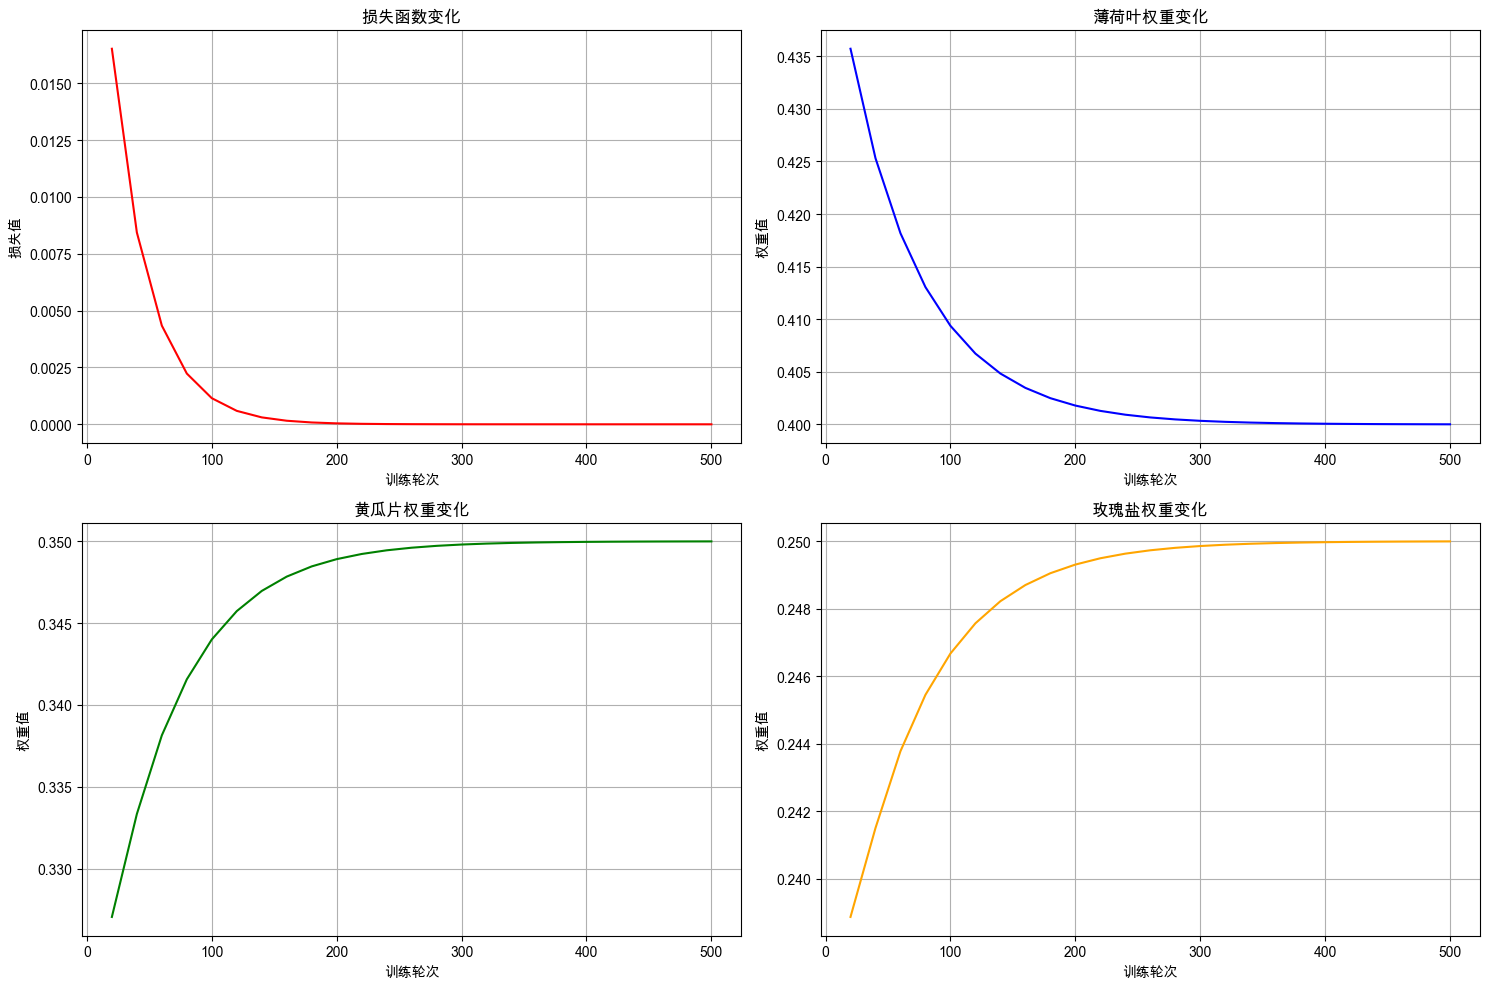

In [9]:
from util import plot_training_logs

# 绘制训练日志图像
plot_training_logs(training_logs)

从训练的过程中我们可以看到，所有参数在约 200 轮后基本收敛，三个配料权重都趋于稳定，说明模型确实找到了它们的配比与顾客评分之间的关系。而且总体来看，变化的趋势很平滑，说明模型训练过程非常稳定。

## 模型评估

模型训练完成后，需要评估模型在未见过的新数据上的表现，即评估模型的泛化能力。具体步骤如下：
1. 评估时，使用 `torch.no_grad()` 关闭梯度计算，可以在推理过程中不存储中间结果，减少显存占用
2. 将评估数据转换为 Pytorch 张量
3. 使用训练好的模型对新的柠檬水进行评分
4. 计算预测评分和真实评分的偏差和精度

In [10]:
# 模型评估

# 1️⃣ 关闭梯度计算
with torch.no_grad():  

    # 2️⃣ 将输入特征转换为张量格式
    val_features_tensor = torch.tensor(val_features, dtype=torch.float32)  

    # 3️⃣ 使用训练好的模型对柠檬水进行评分
    predicted = model(val_features_tensor).numpy()  

    # 4️⃣ 计算预测评分和真实评分的偏差和精度
    data = []
    for i in range(len(val_features)):
        residual = predicted[i][0] - val_targets[i][0]  # 预测的偏差
        accuracy_ratio = 1 - abs(residual) / val_targets[i][0]  # 预测的精度

        data.append({
            "薄荷叶": val_features[i][0],
            "黄瓜片": val_features[i][1],
            "玫瑰盐": val_features[i][2],
            "真实评分": val_targets[i][0],
            "模型预测": predicted[i][0],
            "模型偏差": f"{residual:.4f}",
            "模型精度": f"{accuracy_ratio * 100:.2f}%"
        })

    show_table(data)

,薄荷叶,黄瓜片,玫瑰盐,真实评分,模型预测,模型偏差,模型精度
0,1,8,2,3.7000,3.6999,-0.0001,100.00%
1,1,2,3,1.8500,1.8500,-0.0000,100.00%
2,9,8,3,7.1500,7.1500,0.0000,100.00%
3,1,10,9,6.1500,6.1499,-0.0001,100.00%
4,1,3,9,3.7000,3.6999,-0.0001,100.00%
...,...,...,...,...,...,...,...
195,9,1,2,4.4500,4.4501,0.0001,100.00%
196,10,4,6,6.9000,6.9001,0.0001,100.00%
197,9,5,6,6.8500,6.8500,0.0000,100.00%
198,4,7,3,4.8000,4.8000,-0.0000,100.00%


从评估结果中可以看出，模型在预测柠檬水评分时，基本保持了预测的偏差在 `±0.01` 的范围内，准确率也基本保持在 `99.99%` 以上。说明我们的模型成功学习到了薄荷叶、黄瓜片、玫瑰盐与顾客评分之间的关系，并且在验证集上的表现良好，说明训练出的模型具有较好的泛化能力，完美的完成了本次的任务。

## 为什么模型总是训不好？

虽然我们已经完美的完成了本次任务，但是很多同学在刚开始手动训练模型时，常常会遇到训练失败的情况。在前面的训练过程中，我们可以看到和模型训练相关的因素主要有两个：**训练数据量**和**学习率**。

下面我们设计3个实验，对比不同数据量和学习率对训练结果的影响：

| 实验   | 实验设置              |
|--------|-----------------------|
| 实验 1 | 样本数多，学习率低      |
| 实验 2 | 样本数多，学习率高      |
| 实验 3 | 样本数少，学习率高      |


### 实验1：样本数多，学习率低
- 训练轮数：`100`
- 样本数：`800`
- 学习率：`0.001`

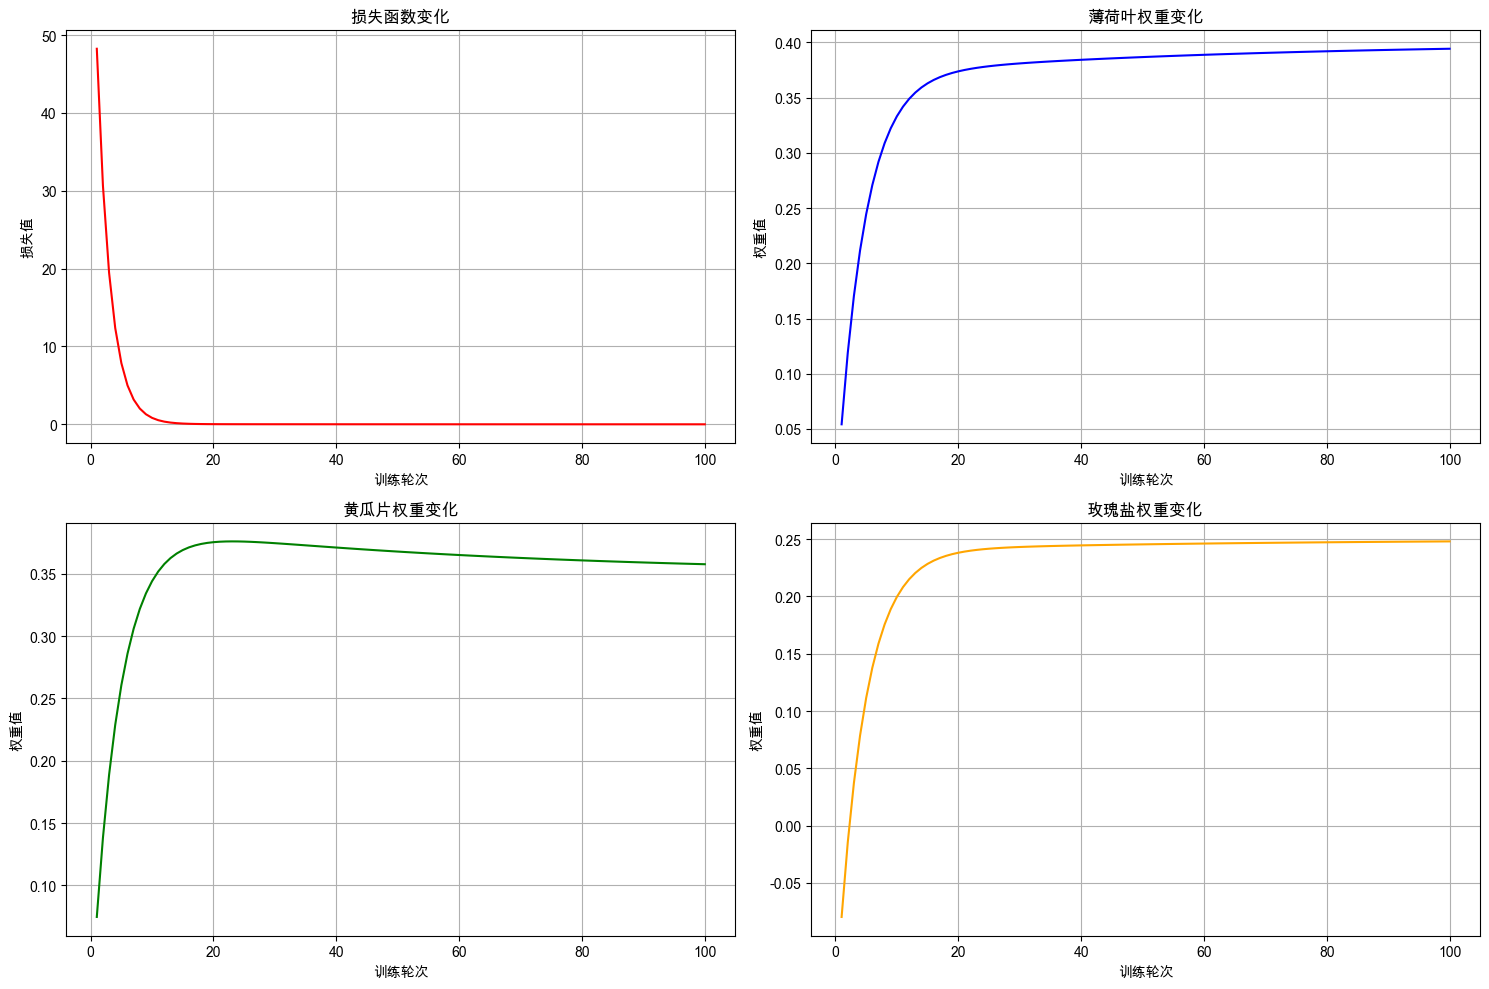

In [11]:
# 1️⃣ 超参数配置
num_epochs = 100
samples_num = 800
lr = 0.001

# 2️⃣ 将数组转换为 PyTorch 张量
train_features_tensor = torch.tensor(train_features[:samples_num], dtype=torch.float32)
train_targets_tensor = torch.tensor(train_targets[:samples_num], dtype=torch.float32)

# 3️⃣ 定义损失函数和优化器
model = LemonadeRatingModel()  # 创建模型实例
loss_fn = nn.MSELoss()  # 使用均方误差损失函数
optimizer = torch.optim.SGD(model.parameters(), lr=lr)  # 使用随机梯度下降优化器

# 4️⃣ 调用训练方法
training_logs = train_model(model, train_features_tensor, train_targets_tensor, loss_fn, optimizer, num_epochs=num_epochs, log_interval=1)

# 5️⃣ 可视化训练过程
plot_training_logs(training_logs)

从 `实验1` 中，我们可以看到，损失下降速度较慢但稳定，训练过程平滑，没有有剧烈波动。

### 实验2：样本数多，学习率高
- 训练轮数：`100`
- 样本数：`800`
- 学习率：`0.009`

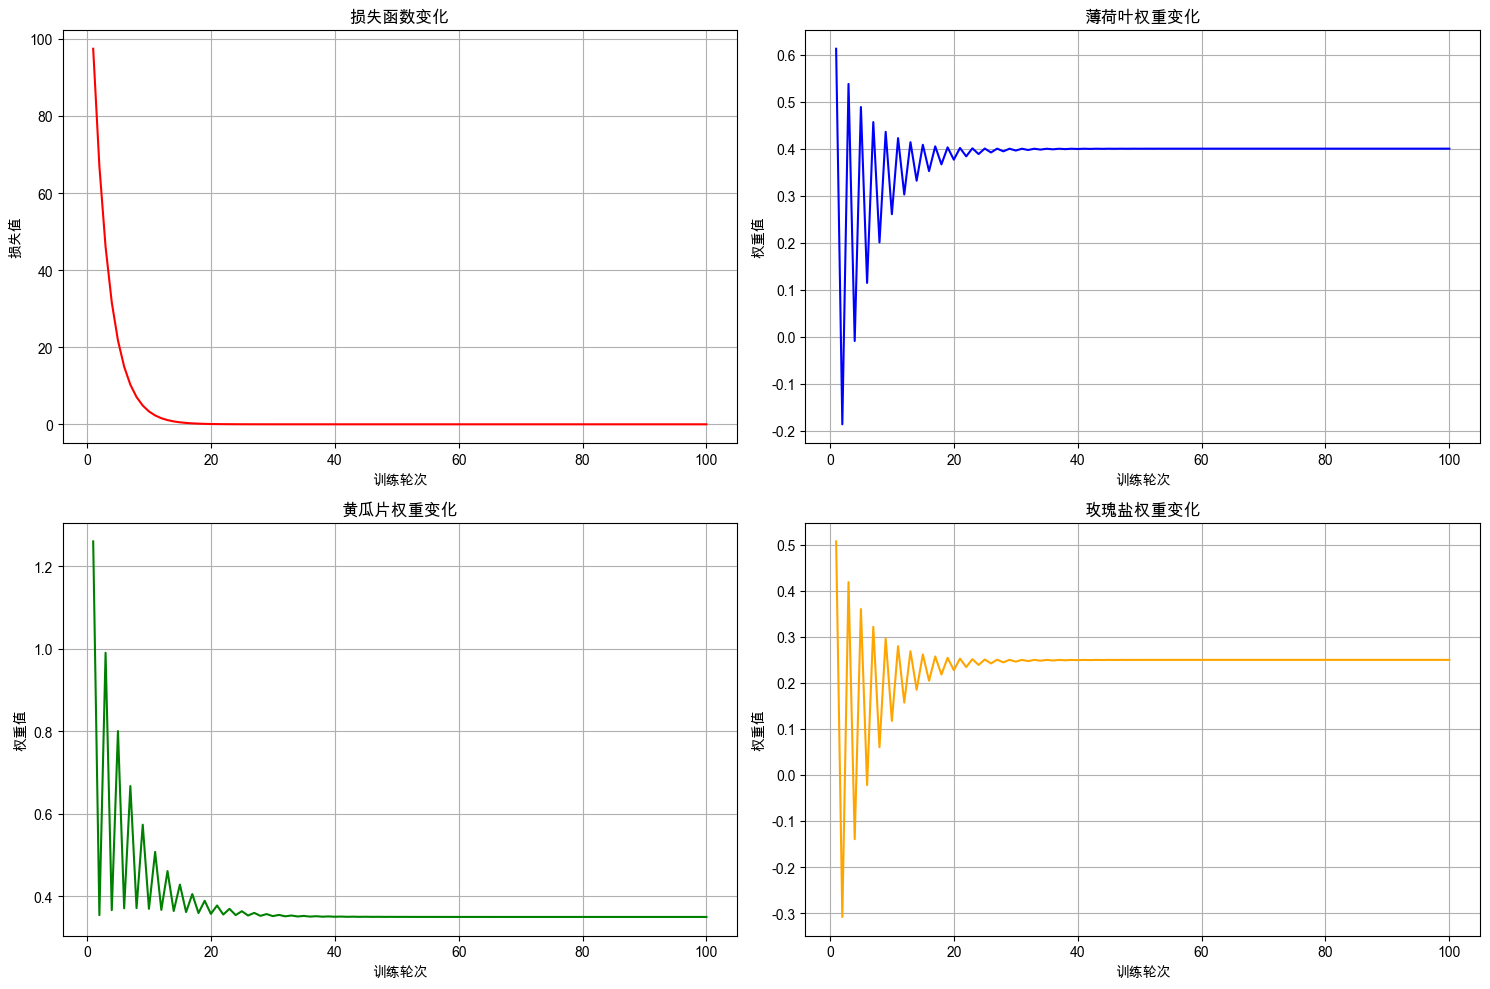

In [12]:
# 1️⃣ 超参数配置
num_epochs = 100
samples_num = 800
lr = 0.009


# 2️⃣ 将数组转换为 PyTorch 张量
train_features_tensor = torch.tensor(train_features[:samples_num], dtype=torch.float32)
train_targets_tensor = torch.tensor(train_targets[:samples_num], dtype=torch.float32)

# 3️⃣ 定义损失函数和优化器
model = LemonadeRatingModel()  # 创建模型实例
loss_fn = nn.MSELoss()  # 使用均方误差损失函数
optimizer = torch.optim.SGD(model.parameters(), lr=lr)  # 使用随机梯度下降优化器

# 4️⃣ 调用训练方法
training_logs = train_model(model, train_features_tensor, train_targets_tensor, loss_fn, optimizer, num_epochs=num_epochs, log_interval=1)

# 5️⃣ 可视化训练过程
plot_training_logs(training_logs)

从 `实验2` 中，我们可以看到，当学习率增大时，损失下降速度较快，在第 20 轮权重的值就接近最优值了。虽然增大学习率能加快模型的训练速度，但训练的过程存在剧烈波动，训练过程不平滑，有较大的风险训练失败。

### 实验3：样本数少，学习率高
- 训练轮数：`100`
- 样本数：`5`
- 学习率：`0.009`

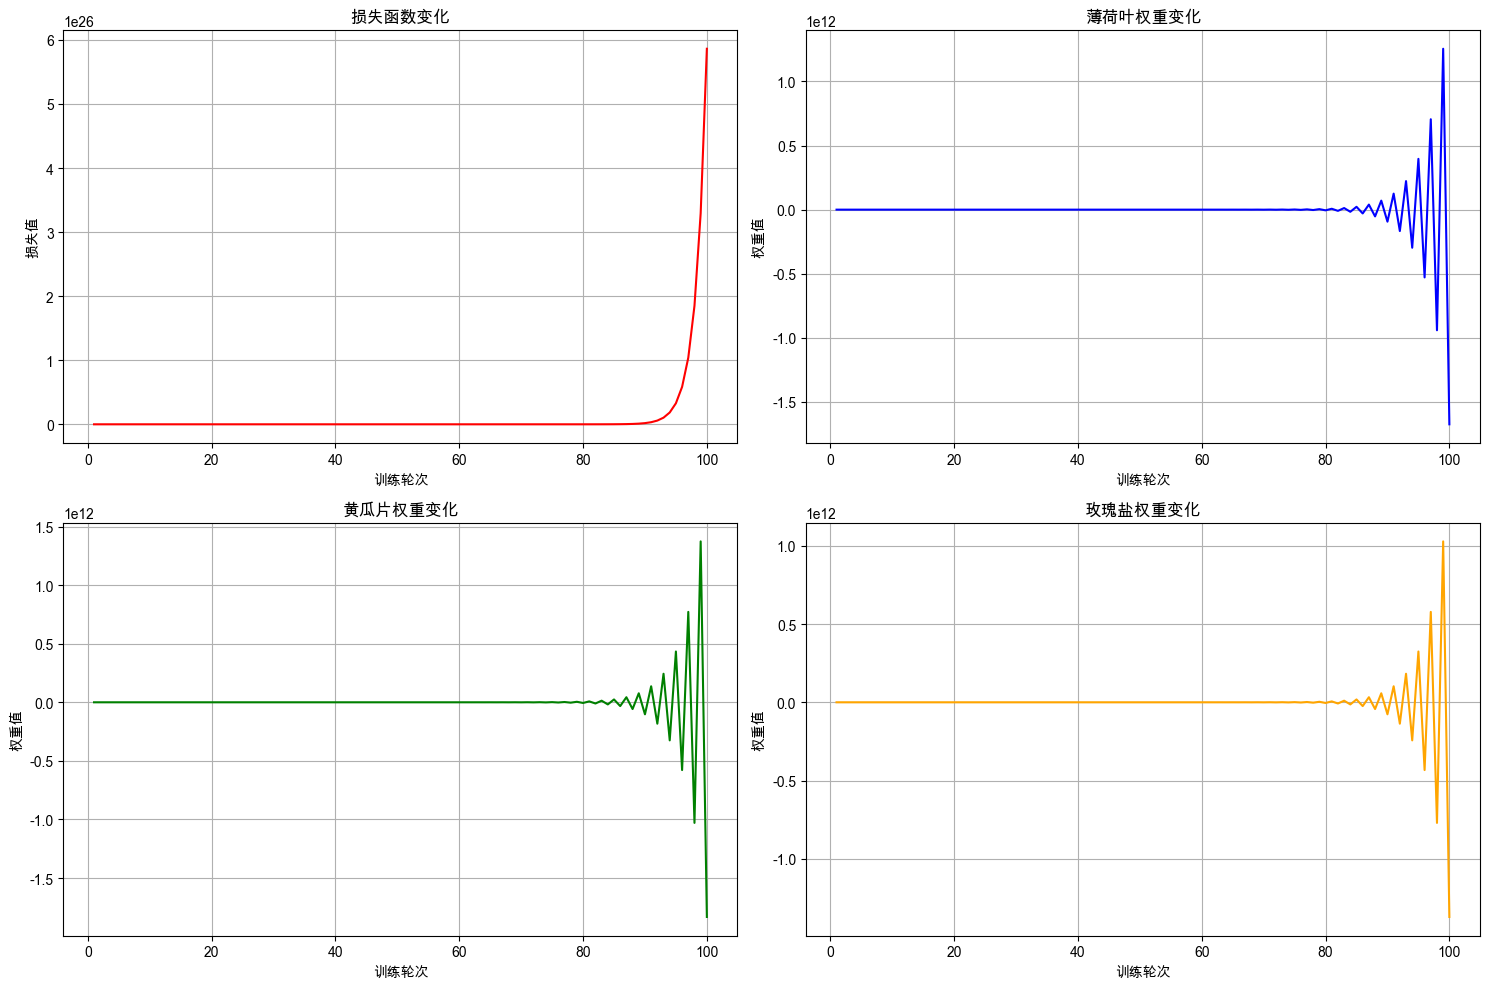

In [13]:
# 1️⃣ 超参数配置
num_epochs = 100
samples_num = 5
lr = 0.009

# 2️⃣ 将数组转换为 PyTorch 张量
train_features_tensor = torch.tensor(train_features[:samples_num], dtype=torch.float32)
train_targets_tensor = torch.tensor(train_targets[:samples_num], dtype=torch.float32)

# 3️⃣ 定义损失函数和优化器
model = LemonadeRatingModel()  # 创建模型实例
loss_fn = nn.MSELoss()  # 使用均方误差损失函数
optimizer = torch.optim.SGD(model.parameters(), lr=lr)  # 使用随机梯度下降优化器

# 4️⃣ 调用训练方法
training_logs = train_model(model, train_features_tensor, train_targets_tensor, loss_fn, optimizer, num_epochs=num_epochs, log_interval=1)

# 5️⃣ 可视化训练过程
plot_training_logs(training_logs)

从结果中我们可以看到 `实验3` 训练彻底失败。和 `实验2` 相比，它只训练了 5 个样本，训练数据过少导致训练失败。这说明：“数据就是智能的燃料”，就像一个火箭就算有再强的引擎，如果没有足够的燃料也无法到达期望的目的地。

这是本实验的关键教训：
- 当数据量不足时，模型无法学习到真正的规律。
- 越是复杂的模型训练所需的数据量越大。

### 实验的启示

通过这三组对比实验，我们系统分析了不同样本量与学习率的组合对模型训练的影响，具体实验设置及结果如下：
- `实验1`：采用多样本量、低学习率设置 → 训练过程稳定，但收敛速度缓慢；
- `实验2`：采用多样本量、高学习率设置 → 训练收敛速度加快，但过程波动剧烈；
- `实验3`：采用少样本量、高学习率设置 → 训练直接失败。

上述三组实验结果为我们提供了一些关键启示：
- **首先，学习率对训练效果存在双重影响，需精准平衡。** 
    - 过小的学习率会显著延长训练周期，会降低训练效率，浪费大量的时间和算力成本；
    - 提升学习率虽能有效加速训练收敛，但会破坏训练稳定性，甚至可能导致训练失效。

因此，好的学习率调度策略对模型的训练至关重要。在后续项目中，我们会采用更先进的优化器动态调度学习率，让模型在训练过程又快又好。

- **其次，数据对模型训练效果具有根本性决定作用。**
数据量不足或质量欠佳，会直接导致训练失败。不少 AI 项目失败的原因，都在于对高质量数据采集的重视不足，反而过度将资源倾斜于模型开发与改进。事实上，数据采集的优先级应高于模型本身，其质量与数量直接决定项目成败，是 AI 项目实施过程中的至关重要的环节。

## 本章小结

本章使用 PyTorch 训练了我们的第一个神经网络模型。我们掌握了如何使用 PyTorch 训练一个多参数的回归模型，并理解了神经网络模型的构建、训练过程以及损失函数和优化器的作用。这为理解深度学习框架的工作机制奠定了坚实基础。但是，在训练过程中，我们的数据还是比较低效的手动管理，在下一个章节中我们将学习如何使用更深的网络、更高效的数据管理方式处理更复杂的多分类问题。

## 答疑讨论

```{div} alert alert-light simple-tilt custom-card

<a href="https://t.zsxq.com/mAjcy" onclick="LA.track('qa'); return true;">
    <div>
        <div style="display: flex; align-items: center">
            <img src="https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/logo.png" style="width: 128px">
            <div style="margin-left: 20px">
                <h4 class="card-title mt-3">答疑讨论</h4>
                <p class="card-text">
                    如果你有任何学习上的疑问，可以评论留言，和我一起讨论。我会抽空回复你的问题，也欢迎你回答其他人的问题。
                </p>
            </div>
        </div>
    </div>
</a>
```